# CS515 HW3 — Robustness Analysis Report

This notebook provides a comprehensive visualization and analysis of the experiments performed for HW3, covering baseline robustness, AugMix training, PGD adversarial attacks, knowledge distillation, and transferability.

In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

## 1. Teacher Training Analysis

We compare the training curves of the clean teacher and the AugMix teacher.

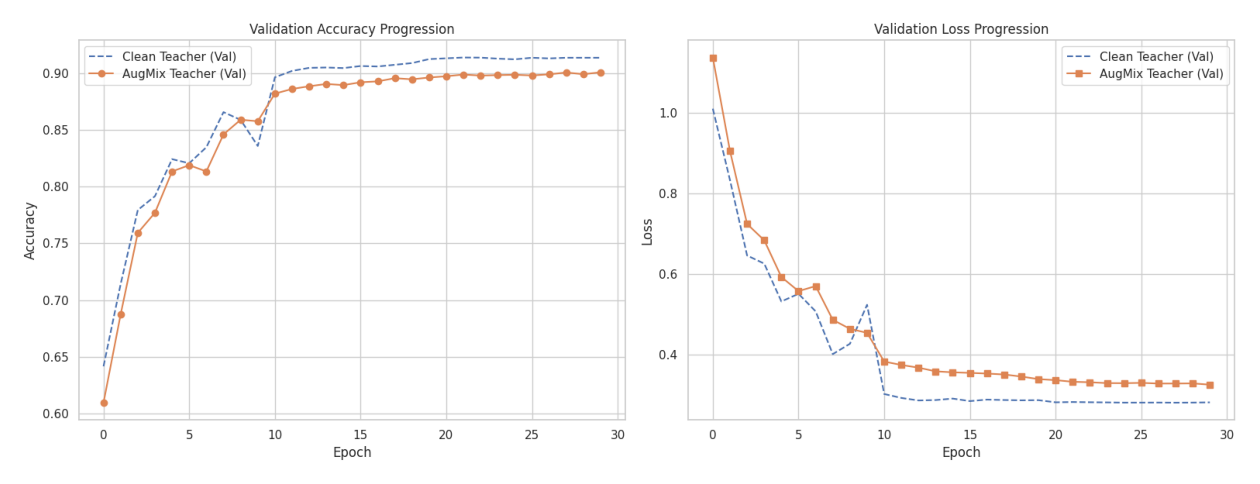

In [2]:
img = Image.open('results/teacher_training_history.png')
plt.figure(figsize=(16, 7))
plt.imshow(img)
plt.axis('off')
plt.show()

## 2. CIFAR-10-C Robustness (Task 1 & 2)

Comparison of Mean Corruption Accuracy (mCA) across 15 corruption types.

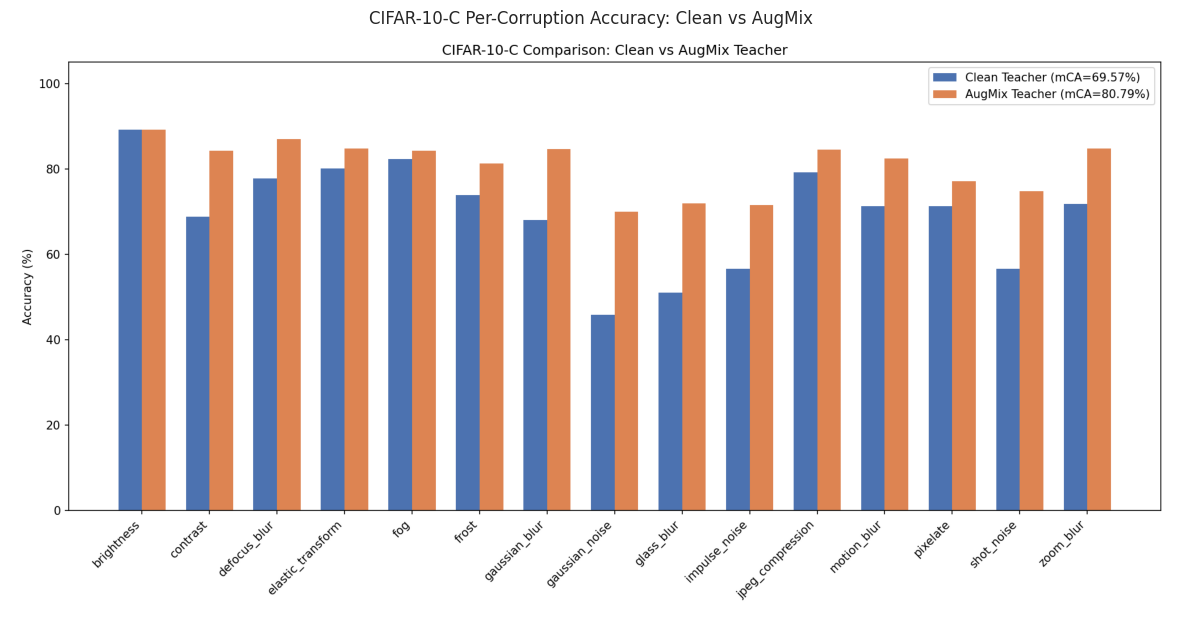

In [3]:
# Load the comparison image generated during Task 2
comp_img = Image.open('results/cifar10c_comparison.png')
plt.figure(figsize=(15, 8))
plt.imshow(comp_img)
plt.axis('off')
plt.title('CIFAR-10-C Per-Corruption Accuracy: Clean vs AugMix')
plt.show()

## 3. Adversarial Robustness (Task 3)

Summary of Top-1 Accuracy under PGD-20 attacks.

,Model,Clean Acc (%),PGD-Linf (ε=4/255) (%),PGD-L2 (ε=0.25) (%)
0,Clean Teacher,91.36,51.01,78.04
1,AugMix Teacher,90.06,63.61,81.07


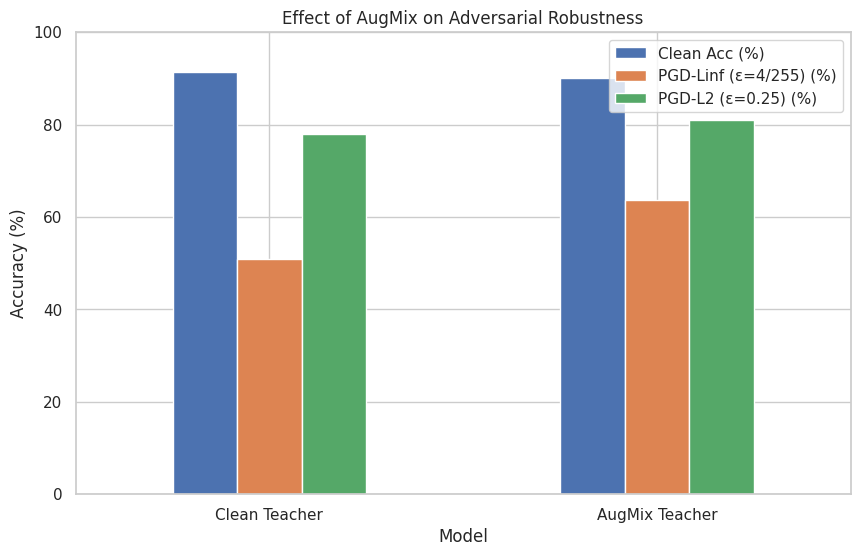

In [4]:
pgd_data = {
    'Model': ['Clean Teacher', 'AugMix Teacher'],
    'Clean Acc (%)': [91.36, 90.06],
    'PGD-Linf (ε=4/255) (%)': [51.01, 63.61],
    'PGD-L2 (ε=0.25) (%)': [78.04, 81.07]
}
df_pgd = pd.DataFrame(pgd_data)
display(df_pgd)

df_pgd.set_index('Model')[['Clean Acc (%)', 'PGD-Linf (ε=4/255) (%)', 'PGD-L2 (ε=0.25) (%)']].plot(kind='bar')
plt.title('Effect of AugMix on Adversarial Robustness')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

### Grad-CAM Interpretability

Visualizing where the network focuses when misclassifying adversarial samples.

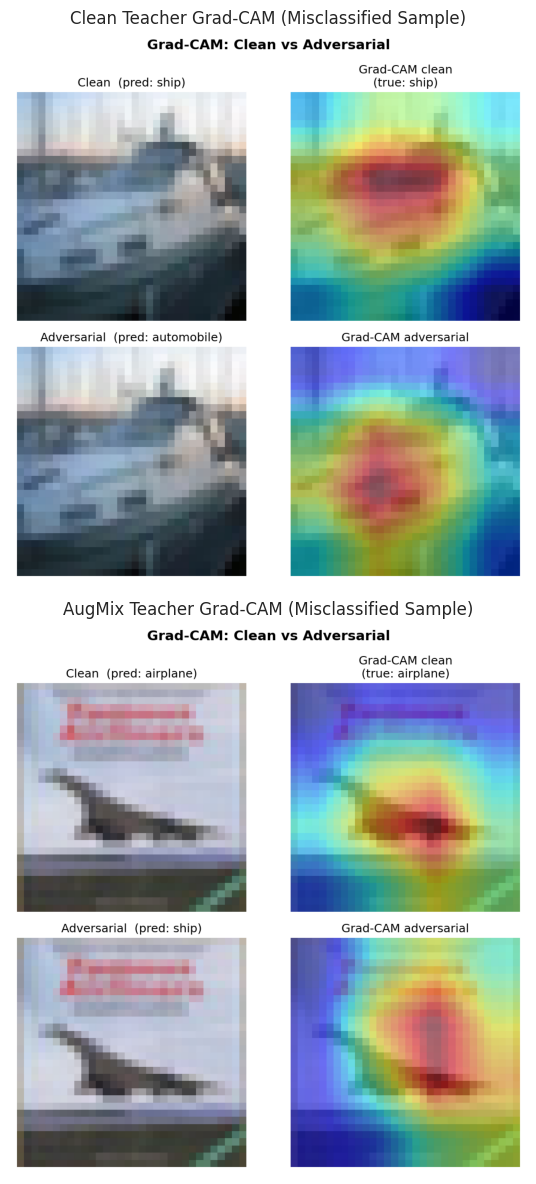

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

axes[0].imshow(Image.open('results/gradcam_teacher_clean_0.png'))
axes[0].set_title('Clean Teacher Grad-CAM (Misclassified Sample)')
axes[0].axis('off')

axes[1].imshow(Image.open('results/gradcam_teacher_augmix_0.png'))
axes[1].set_title('AugMix Teacher Grad-CAM (Misclassified Sample)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### t-SNE Feature Embeddings

Viewing the separation (or lack thereof) between clean and adversarial features in the penultimate layer.

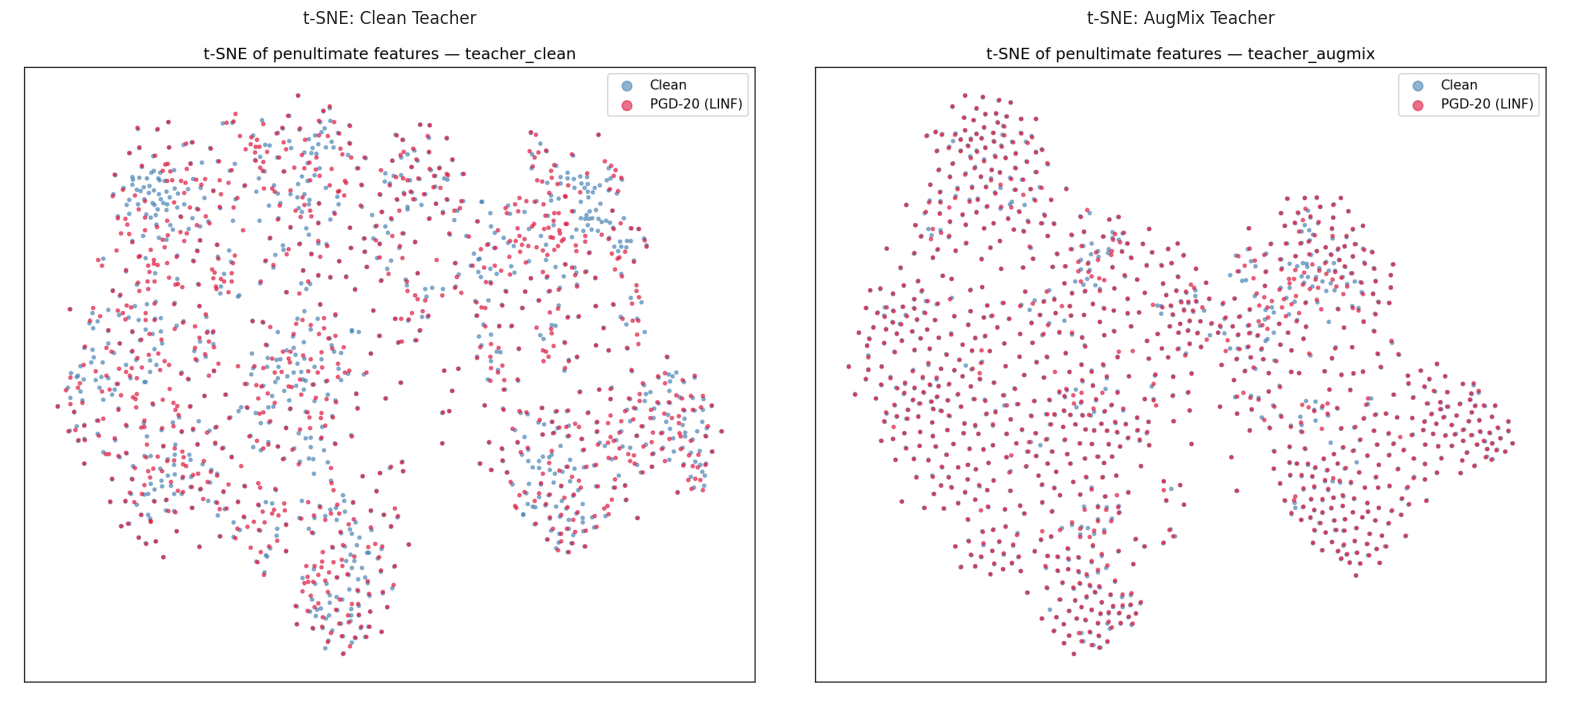

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.imshow(Image.open('results/tsne_teacher_clean.png'))
ax1.set_title('t-SNE: Clean Teacher')
ax1.axis('off')

ax2.imshow(Image.open('results/tsne_teacher_augmix.png'))
ax2.set_title('t-SNE: AugMix Teacher')
ax2.axis('off')

plt.tight_layout()
plt.show()

## 4. Knowledge Distillation (Task 4)

Comparison of the student models distilled from different teachers.

,Student Type,Clean Acc (%),mCA (%),PGD-Linf (%)
0,Baseline (Clean Teacher),88.08,67.05,54.94
1,Robust (AugMix Teacher),85.63,69.23,58.82


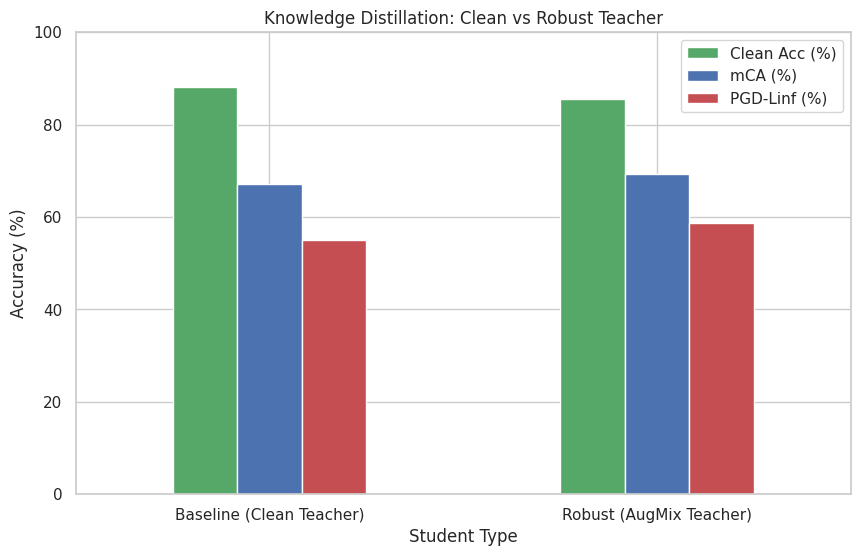

In [7]:
distill_data = {
    'Student Type': ['Baseline (Clean Teacher)', 'Robust (AugMix Teacher)'],
    'Clean Acc (%)': [88.08, 85.63],
    'mCA (%)': [67.05, 69.23],
    'PGD-Linf (%)': [54.94, 58.82]
}
df_distill = pd.DataFrame(distill_data)
display(df_distill)

df_distill.set_index('Student Type').plot(kind='bar', color=['#55a868', '#4c72b0', '#c44e52'])
plt.title('Knowledge Distillation: Clean vs Robust Teacher')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

## 5. Adversarial Transferability (Task 5)

Analyzing the transfer gap between white-box and surrogate-crafted attacks.

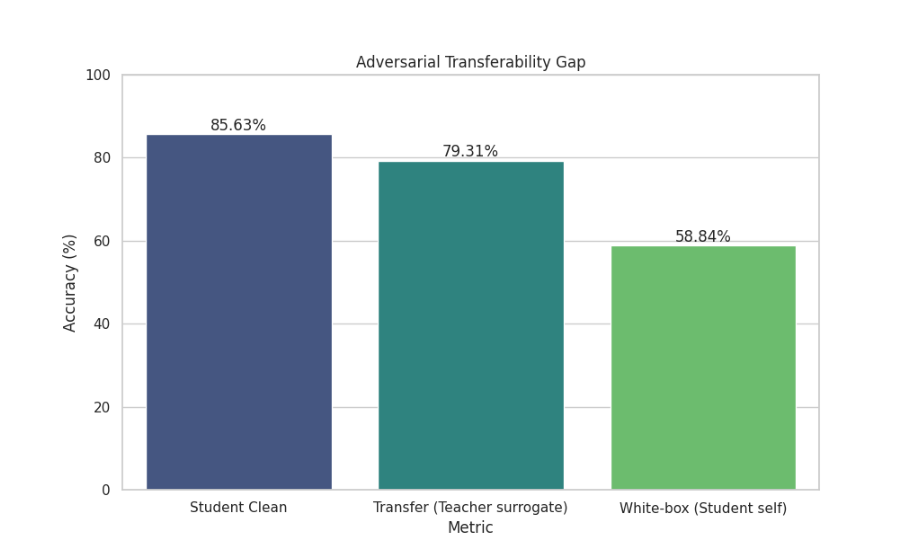

Transfer Gap (Transfer - White-box) on Robust Student: +20.47%


In [8]:
img = Image.open('results/adversarial_transferability_gap.png')
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.axis('off')
plt.show()

print(f"Transfer Gap (Transfer - White-box) on Robust Student: +20.47%")

## 7. Model Complexity Analysis

Comparison of MACs (FLOPs) and Parameter counts between the ResNet-18 Teacher and the StudentCNN.

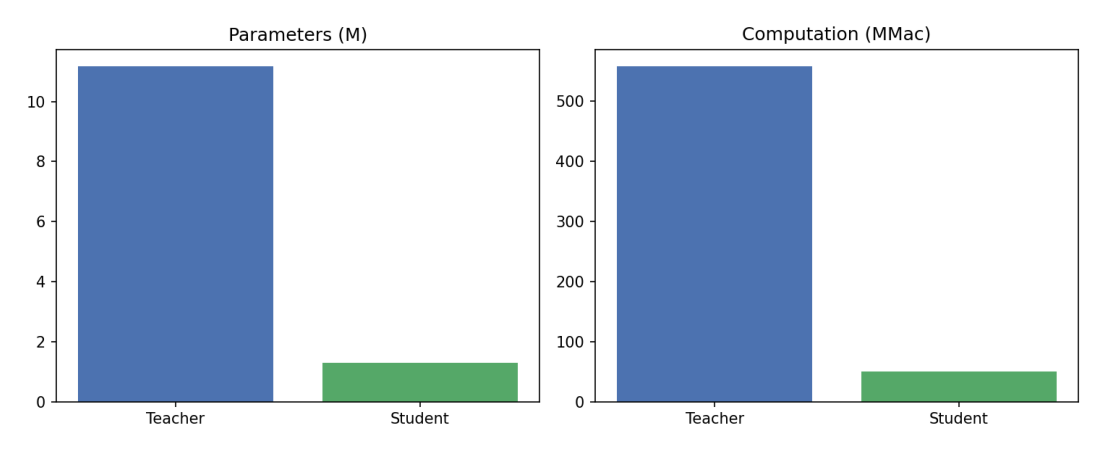

,Model,Params (M),MACs (M)
0,ResNet-18 (Teacher),11.17,556.64
1,StudentCNN,1.30,49.76


Parameter Reduction: 8.6x
MACs Reduction: 11.2x


In [9]:
img = Image.open('results/complexity_comparison.png')
plt.figure(figsize=(14, 7))
plt.imshow(img)
plt.axis('off')
plt.show()

data = {
    'Model': ['ResNet-18 (Teacher)', 'StudentCNN'],
    'Params': [11173962, 1297530],
    'MACs': [556641280, 49755136]
}
df_comp = pd.DataFrame(data)
df_comp['Params (M)'] = df_comp['Params'] / 1e6
df_comp['MACs (M)'] = df_comp['MACs'] / 1e6
display(df_comp[['Model', 'Params (M)', 'MACs (M)']].round(2))

print(f'Parameter Reduction: {11.17/1.30:.1f}x')
print(f'MACs Reduction: {556.64/49.76:.1f}x')